In [1]:
import os
import sys
from pathlib import Path
import yaml

learned_control = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(learned_control)
sys.path.append(os.path.join(learned_control, "simulator_lidar"))
sys.path.append(os.path.join(learned_control, "CARV"))

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from simulator_lidar import run_simulation
from CARV.nfl_robustness_training.src.utils import mpc_unicycle

dir_path = /Users/dgaillard/Desktop/aerospace_controls_lab/learned_control/safety_verification/src/CARV


/Users/dgaillard/.pyenv/versions/3.11.11/lib/python3.11/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/Users/dgaillard/.pyenv/versions/3.11.11/lib/python3.11/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


In [3]:
def generate_yaml_config(parent_dir, environment, radius=1.0, overwrite=False):
    """
    Generate YAML configuration file with specified obstacles in a config subdirectory
    
    Args:
        parent_dir (str): Parent directory containing config subdirectory
        environment (str): Name of environment/file (will create environment.yaml)
        overwrite (bool): Allow overwriting existing files
    """
    # Create config subdirectory path
    config_dir = os.path.join(parent_dir, 'config/obstacle_config')
    os.makedirs(config_dir, exist_ok=True)
    
    # Create file path
    yaml_path = os.path.join(config_dir, f'{environment}.yaml')
    
    # Check if file exists
    if os.path.exists(yaml_path) and not overwrite:
        overwrite = input(f"File {yaml_path} exists. Overwrite? [y/N] ").lower() == 'y'
        if not overwrite:
            print("Aborting file creation")
            return

    # Base configuration structure
    config_data = {
        'area': {
            'x_min': -10,
            'x_max': 10,
            'y_min': -10,
            'y_max': 10
        },
        'obstacles': [
            {
                'centroid_x': 0,
                'centroid_y': 0,
                'radius': radius,
                'velocity_x': 0,
                'velocity_y': 0,
                'acc_x': 0,
                'acc_y': 0,
                'circle': True
            }
        ]
    }

    # Write YAML file with proper formatting
    with open(yaml_path, 'w') as f:
        yaml.dump(config_data, f, 
                 default_flow_style=False,  # Preserve block style
                 sort_keys=False)  # Maintain order

    print(f"Created config file at: {yaml_path}")

In [4]:
def generate_start_positions(num_samples, obstacle_radius, min_distance=1.2, max_distance=3.0):
    """
    Generate random start and goal positions around a circular obstacle at origin
    using uniform angular distribution and controlled radial distribution
    
    Args:
        num_samples: Total number of position pairs to generate
        obstacle_radius: Radius of central obstacle (r)
        min_distance: Minimum distance from obstacle edge (multiple of r)
        max_distance: Maximum distance from obstacle center (multiple of r)
    
    Returns:
        Tuple of (start_positions, goal_positions) each with shape (num_samples, 2)
    """
    def generate_positions(n):
        r_min = obstacle_radius * min_distance
        r_max = obstacle_radius * max_distance
        theta = np.random.uniform(0, 2*np.pi, n)
        u = np.random.uniform(0, 1, n)
        radii = np.sqrt(u*(r_max**2 - r_min**2) + r_min**2)
        x = radii * np.cos(theta)
        y = radii * np.sin(theta)
        return np.column_stack((x, y))

    starts = generate_positions(num_samples)
    goals = generate_positions(num_samples)
    return starts, goals

def create_dataset(parent_dir, obstacle_radius, total_samples=1000, splits=(0.7, 0.15, 0.15), min_distance=1.2, max_distance=3.0, save_data=True):
    """
    Create train/test/validation splits for obstacle avoidance dataset with start-goal pairs
    
    Args:
        parent_dir (str): Parent directory containing config subdirectory
        obstacle_radius (float): Radius of central obstacle
        total_samples (int): Total number of samples to generate
        splits (tuple[float]): Tuple of (train_ratio, test_ratio, val_ratio)
    """
    assert abs(sum(splits) - 1.0) < 1e-6, "Splits must sum to 1"
    
    # Generate all position pairs
    starts, goals = generate_start_positions(total_samples, obstacle_radius, 
                                           min_distance=min_distance, max_distance=max_distance)
    
    # Shuffle and split indices while maintaining start-goal correspondence
    indices = np.random.permutation(total_samples)
    train_end = int(splits[0] * total_samples)
    test_end = train_end + int(splits[1] * total_samples)
    
    dataset = {
        'train': {
            'start': starts[indices[:train_end]],
            'goal': goals[indices[:train_end]]
        },
        'test': {
            'start': starts[indices[train_end:test_end]],
            'goal': goals[indices[train_end:test_end]]
        },
        'validation': {
            'start': starts[indices[test_end:]],
            'goal': goals[indices[test_end:]]
        }
    }
    
    if save_data:
        config_dir = os.path.join(parent_dir, f'config/position_config')
        os.makedirs(config_dir, exist_ok=True)

        for split in ['train', 'test', 'validation']:
            np.save(os.path.join(config_dir, f'{split}_starts_rad_{obstacle_radius:.3f}.npy'), dataset[split]['start'])
            np.save(os.path.join(config_dir, f'{split}_goals_rad_{obstacle_radius:.3f}.npy'), dataset[split]['goal'])
        print(f"Saved datasets with start-goal pairs to {config_dir}")
    
    return dataset

def plot_positions(positions, obstacle_radius):
    """Visualize generated positions with obstacle (original function preserved)"""
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot obstacle
    obstacle = plt.Circle((0, 0), obstacle_radius, 
                         color='r', alpha=0.3, label='Obstacle')
    ax.add_patch(obstacle)
    
    # Plot positions
    ax.scatter(positions[:,0], positions[:,1], s=5, alpha=0.5)
    
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Positions Around Obstacle (r={obstacle_radius})')
    plt.legend()
    plt.show()


In [5]:
# radii = np.linspace(0.5, 3, 5)
radii = [3]
parent_dir=os.path.join(learned_control, "safety_verification")
# Create config files with varying obstacle sizes
for r in radii:
    generate_yaml_config(
        parent_dir=parent_dir, #"/path/to/your/parent/directory",
        environment=f"data_gen_config_rad_{r:.3f}",
        radius=float(r),
        overwrite=True
    )

    dataset = create_dataset(parent_dir, r, total_samples=1, min_distance=1.5)

    # plot_positions(dataset['train']['goal'], r)

Created config file at: /Users/dgaillard/Desktop/aerospace_controls_lab/learned_control/safety_verification/config/obstacle_config/data_gen_config_rad_3.000.yaml
Saved datasets with start-goal pairs to /Users/dgaillard/Desktop/aerospace_controls_lab/learned_control/safety_verification/config/position_config


In [ ]:
# Read files and get mpc trajectories + simulated lidar scans
def load_raw_data(parent_dir, obstacle_radius, split='train'):
    """
    Load start and goal positions from saved .npy files
    
    Args:
        parent_dir (str): Parent directory containing config/position_config
        obstacle_radius (float): Radius used when creating the dataset
        split (str): One of 'train', 'test', or 'validation'
    
    Returns:
        Tuple of (start_positions, goal_positions) as NumPy arrays
    """
    config_dir = os.path.join(parent_dir, 'safety_verification/config/position_config')
    rad_str = f"{obstacle_radius:.3f}"
    
    try:
        starts = np.load(os.path.join(config_dir, f'{split}_starts_rad_{rad_str}.npy'))
        goals = np.load(os.path.join(config_dir, f'{split}_goals_rad_{rad_str}.npy'))
    except FileNotFoundError as e:
        raise ValueError(f"Dataset not found for radius {obstacle_radius} and split {split} \n failed path: {os.path.join(config_dir, f'{split}_starts_rad_{rad_str}.npy')}") from e
    
    for i in range(starts.shape[0]):
        start = starts[i,:].tolist()
        start.append(np.random.uniform(-np.pi, np.pi))
        goal = goals[i,:].tolist()

        print(f"calculating mpc trajectory {i} in split {split} with start {start} and goal {goal}")
        mpc_unicycle.generate_data(
            num_trajectories=1, 
            noisy=False, 
            prob_short=0.0, 
            use_config=True, 
            environment=f"/data_gen_config_rad_{rad_str}", 
            config_path=os.path.join(learned_control, "safety_verification/config/obstacle_config"),
            save_parent_dir=learned_control,
            save_filename=f"{split}_mpc_traj_rad_{rad_str}_{i}.pkl",
            plot=True,
            start=start,
            goal=goal,
        )
    
    return starts, goals

calculating mpc trajectory 0 in split validation with start [-5.8459498734940505, 2.1559329742947617, 0.36259039793399594] and goal [-5.965618248216248, -1.612137776245221]
MPC IS USING PROVIDED START: [-5.8459498734940505, 2.1559329742947617, 0.36259039793399594]
the x0s used is [[-5.84594987  2.15593297  0.3625904 ]]
############################################################################################
#################################### Trajectory 0 #########################################
############################################################################################
############################################################################################

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
*

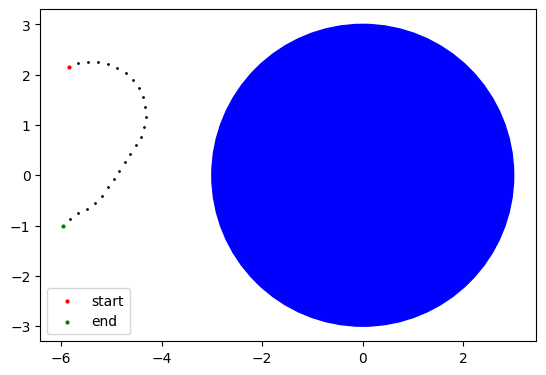

data saved to /Users/dgaillard/Desktop/aerospace_controls_lab/learned_control/safety_verification/data_raw/validation_mpc_traj_rad_3.000_0.pkl


In [7]:
for r in radii:
    for split in ['train', 'test', 'validation']:
        load_raw_data(learned_control, r, split)

In [ ]:
# run_simulation.main(
#     env = 'safety_test2', 
#     out_fn = 'safety_setting2', 
#     out_file_type = 'carmen', 
#     save_all_data_as_npz = False,
#     n_reflections = 24, 
#     fov= 360, 
#     max_laser_distance = 12,
#     unoccupied_points_per_meter= 0.5, 
#     pose_filepath='/Users/dgaillard/Desktop/aerospace_controls_lab/learned_control/CARV/nfl_robustness_training/src/_static/datasets/unicycle/double_obstacle_aug/dataset.pkl'
# )
# # raw_starts = []
# # raw_goals = []
# # for r in radii:
# #     # Load raw data
# #     train_starts, train_goals = load_raw_data(
# #         parent_dir=parent_dir,
# #         obstacle_radius=0.5,  # Must match the radius used in create_dataset
# #         split='train'
# #     )
# #     raw_starts.extend(train_starts.tolist())
# #     raw_goals.extend(train_goals.tolist())
# # raw_starts, raw_goals = np.array(raw_starts), np.array(raw_goals)
# # print(raw_starts.shape)


FileNotFoundError: [Errno 2] No such file or directory: 'simulator_lidar/config/safety_test2.yaml'

In [ ]:
# run mpc on raw starts and goals
# for i in range(len(raw_starts)):
#     mpc_unicycle.generate_data(
#         num_trajectories=1, 
#         noisy=False, 
#         prob_short=0.0, 
#         use_config=True, 
#         environment="safety_test2", 
#         config_path="/Users/dgaillard/Desktop/aerospace_controls_lab/learned_control/simulator_lidar/config/",
#         save_parent_dir=learned_control,
#         save_filename=f"mpc_traj_data_{i}",
#     )

In [ ]:
file_path = None
df = pd.read_csv(file_path, delimiter='\s+', header=None)
columns = ['Label'] + [f'angle_idx_{i-1}' for i in range(1, df.shape[1])]
df.columns = columns

numpy_array = df.to_numpy()
X_train = df.to_numpy()[:,2:]
Y_train = None

X_test = None
Y_test = None

# need to fix data generation

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, lidar, actions):
        self.lidar = lidar
        self.actions = actions
    def __len__(self):
        return len(self.lidar)
    def __getitem__(self, idx):
        lidar_tensor = torch.tensor(self.lidar[idx], dtype=torch.float32)
        action = self.actions[idx]
        return lidar_tensor, action

In [ ]:
train_dataset = CustomDataset(X_train, Y_train)
test_dataset = CustomDataset(X_test, Y_test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
class ControlNN(nn.Module):
    def __init__(self, input_size=24, output_size=4, hidden_layers=10, hidden_size=64):
        super(ControlNN, self).__init__()

        layers =  []

        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.ReLU())

        for i in range(hidden_layers-1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(hidden_size, output_size))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)    


In [ ]:
def train_model(model, train_loader, test_loader, device, learning_rate=0.001, num_epochs=30):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        num_samples = 0
        for lidar, action in train_loader:
            lidar, actions = lidar.to(device), action.to(device)
            optimizer.zero_grad()
            outputs = model(lidar)
            loss = criterion(outputs, actions)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * lidar.size(0)
            num_samples += lidar.size(0)

        avg_loss = running_loss / num_samples
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")
    
    model.eval() 
    
    total_loss = 0.0
    total_abs_error = 0.0
    num_samples = 0

    criterion = nn.MSELoss()

    with torch.no_grad():
        for lidar, actions in test_loader:
            lidar, actions = lidar.to(device), actions.to(device)
            
            outputs = model(lidar)

            mse_loss = criterion(outputs, actions)
            total_loss += mse_loss.item() * lidar.size(0)
            total_abs_error += torch.abs(outputs - actions).sum().item() 

            num_samples += lidar.size(0)

    avg_mse_loss = total_loss / num_samples
    avg_abs_error = total_abs_error / num_samples
    
    print(f"Test MSE Loss: {avg_mse_loss:.4f}")
    print(f"Test Mean Absolute Error (MAE): {avg_abs_error:.4f}")
    return model

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ControlNN(device)
model = train_model(model, train_loader, test_loader, device)

In [ ]:
import numpy as np
x0_range = np.array([
        [-10., -9.],
        [3., 4.],
        [-np.pi/6, np.pi/6]
    ])

x0s = np.random.uniform(
    low=x0_range[:, 0],
    high=x0_range[:, 1],
    size=(1, 3),
)
x0s


np.random.uniform(-np.pi, np.pi)

In [ ]:
x0=np.array([[ 4.5164775 ],
 [ 2.40976614],
 [-2.19692645]])
goal=np.array([-4.6509884,   4.39789924])
np.linalg.norm(x0[:2] - np.array(goal).reshape(2,1))
np.linalg.norm((x0[:2]).T - np.array(goal))

print((x0[:2]).T - np.array(goal))
print(x0[:2] - np.array(goal).reshape(2,1))

In [ ]:
"""
plan:

generate position+goal points as part of train test valid in dataset files
store associated mpc trajectories as npy files with states and control inputs
use lidar scan lib to get associated scan data

safety_verification:
    config:
        obstacle_config:
            varoius sizes (small, manual) - DONE
        position_config:
            xy of car and of goal (large, random) - INCOMPLETE
    data_raw:
        traj_data:
            associated mpc trajectories for each line/row of position config - NEED TO RUN
        lidar_data:
            associated lidar scan for each trajectory in traj_data - NEED TO RUN
    data_clean:
        24x lidar scan, goal dist, control input as rows - INCOMPLETE



training:
    train on data_clean

i think that the mpc breaks when the vehicle is facing away from the goal point at the start

"""